<a href="https://colab.research.google.com/github/Jefferson-Luis/previsao-acoes-itub4/blob/main/analise_de_dados_Finance_TechBoost_parte_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Previsão de Preços de Ativos (ITUB4) com Machine Learning

## 🎯 Sobre o Projeto
Este projeto aplica técnicas de Machine Learning (Aprendizado Supervisionado) para prever o preço de fechamento das ações do Itaú Unibanco (ITUB4).

A iniciativa faz parte do meu portfólio prático, unindo a visão de riscos, compliance e governança adquirida em operações críticas do setor financeiro com ferramentas modernas de Ciência de Dados e Inteligência Artificial. O objetivo é demonstrar como a transformação de dados brutos em inteligência preditiva pode apoiar a tomada de decisão no mercado de capitais.

## 🛠️ Tecnologias e Stack
* **Linguagem:** Python
* **Coleta de Dados:** `yfinance` (API do Yahoo Finance)
* **Manipulação e Análise:** `pandas`, `numpy`
* **Machine Learning:** `scikit-learn` (Modelo de Regressão Linear)
* **Visualização de Dados:** `matplotlib` (Storytelling Visual)

## ⚙️ Pipeline do Modelo
O desenvolvimento seguiu as melhores práticas de análise de dados:
1. **Ingestão:** Extração de dados históricos reais da bolsa de valores (preços de Abertura, Alta, Baixa e Fechamento).
2. **Pré-processamento:** Tratamento de valores inconsistentes/nulos e seleção das variáveis independentes (Features) e dependentes (Target).
3. **Divisão de Dados:** Separação da base histórica em Treino (80%) e Teste (20%) para garantir a confiabilidade e evitar *overfitting*.
4. **Treinamento:** Ajuste do modelo preditivo utilizando o algoritmo de Regressão Linear.
5. **Avaliação e Monitoramento:** Medição de performance utilizando a métrica R² e plotagem de gráficos para comparar a predição algorítmica com a realidade do mercado.

## 💼 Visão de Negócio
No cenário bancário atual, antecipar flutuações e entender padrões é essencial. A lógica matemática e estatística aplicada na construção deste modelo de previsão de ativos é a mesma fundação utilizada para modernizar operações financeiras complexas, como:
* Detecção automatizada de fraudes em tempo real.
* Modelagem de *score* e análise de risco de crédito.
* Segmentação e recomendação personalizada de produtos para correntistas.

## 🚀 Como Executar Localmente
1. Clone este repositório: `git clone [URL_DO_SEU_REPOSITORIO]`
2. Instale as bibliotecas necessárias:
   ```bash
   pip install yfinance pandas scikit-learn matplotlib

Baixando dados...


/tmp/ipython-input-1360355487.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados = yf.download(ticker, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Treinando o modelo de Regressão Linear...
Desempenho do Modelo (R²): 0.9965


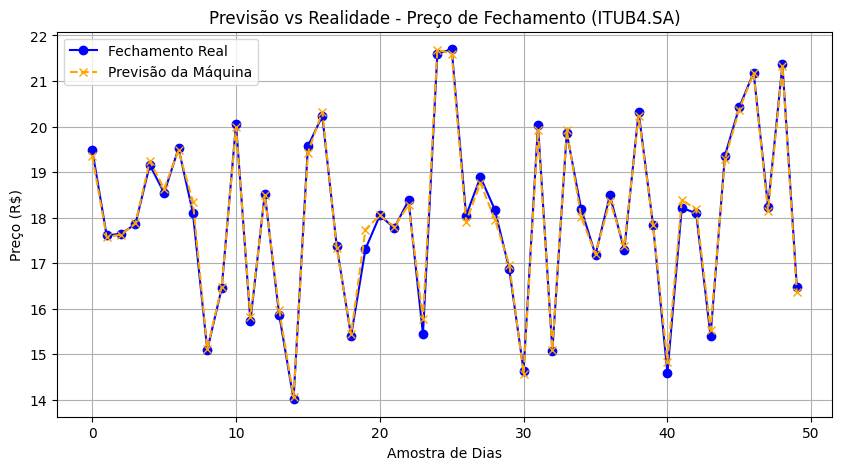

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Coleta de Dados via API do Yahoo Finance
# Vamos puxar o histórico de ações do Itaú Unibanco
print("Baixando dados...")
ticker = "ITUB4.SA"
dados = yf.download(ticker, start="2020-01-01", end="2024-01-01")

# 2. Pré-processamento (Limpeza e Seleção de Variáveis)
# Vamos usar a Abertura (Open), Máxima (High) e Mínima (Low) para prever o Fechamento (Close)
dados = dados[['Open', 'High', 'Low', 'Close']].dropna()

X = dados[['Open', 'High', 'Low']] # Nossas variáveis de entrada
y = dados['Close']                 # O que queremos prever (Target)

# 3. Divisão de Dados: Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Escolha e Treinamento do Modelo (Aprendizado Supervisionado)
print("Treinando o modelo de Regressão Linear...")
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# 5. Avaliação do Modelo (Testando com dados que o modelo nunca viu)
previsoes = modelo.predict(X_test)
r2 = r2_score(y_test, previsoes)
print(f"Desempenho do Modelo (R²): {r2:.4f}")
# O R² varia de 0 a 1. Quanto mais perto de 1, melhor o modelo aprendeu o padrão.

# 6. Storytelling Visual (Plotando uma amostra de 50 dias para comparar)
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label="Fechamento Real", marker='o', color='blue')
plt.plot(previsoes[:50], label="Previsão da Máquina", marker='x', linestyle='dashed', color='orange')
plt.title(f"Previsão vs Realidade - Preço de Fechamento ({ticker})")
plt.xlabel("Amostra de Dias")
plt.ylabel("Preço (R$)")
plt.legend()
plt.grid(True)
plt.show()